In [2]:
import sys, os
sys.path.append(os.path.abspath("../")) 
from conch.open_clip_custom import create_model_from_pretrained, tokenize, get_tokenizer
import torch
import os
from PIL import Image
from pathlib import Path

# show all jupyter output
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

c:\Users\Vivian\anaconda3\envs\conch\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
root = Path('../').resolve()
os.chdir(root)

Load model from checkpoint

In [5]:
model, preprocess = create_model_from_pretrained(model_cfg='conch_ViT-B-16', 
                                                 checkpoint_path=r'C:\Users\Vivian\Documents\CONCH\checkpoints\conch\pytorch_model.bin')
_ = model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device=device)

Open an image and preprocess it

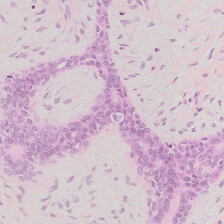

In [ ]:
image = Image.open('./docs/roi1.jpg')

# read numpy file as image
import numpy as np
array = np.load(r'C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\FA\FA 67 B\patch_215_x9856_y1792.npy')
#  C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\FA\FA 67 B\patch_57_x11200_y896.npy

image = Image.fromarray(array)

image_tensor = preprocess(image).unsqueeze(0).to(device)

# visualize thumbnail
image.resize((224, 224))

Load tokenizer and specify some prompts.

In [8]:
tokenizer = get_tokenizer()
# prompts = [
#            'photomicrograph illustrating invasive ductal carcinoma of the breast, H&E stain',
#            'a case of invasive lobular carcinoma as visualized using H&E stain',
#            'high magnification view of a breast cancer tumor, H&E stain',
#            'clear cell renal cell carcinoma',
#            'lung adenocarcinoma, H&E stain',
#            'IHC stain for CDX2 in a case of metastatic colorectal adenocarcinoma',
#            'an image of a cat',
#            'High-grade angiosarcoma characterized by solid areas of polygonal and spindled cells as well as necrosis',
#            'metastatic tumor to the lymph node, GATA3 staining',
#            'epidermis with follicular ostia'
#            ]

prompts = ['stromal condensation around glands',
           'peripheral adipose tissue',
           'normal breast lobules and ducts',
           'minimal/mild hypercellularity',
           'fibroadenoma',
           'gland and stroma',
           'phyllodes tumour',
           'an image of a cat'
           ]

In [9]:
tokenized_prompts = tokenize(texts=prompts, tokenizer=tokenizer).to(device)
tokenized_prompts.shape

torch.Size([8, 128])

Embed the prompts and the image and compute the cosine similarity between the image and the prompts. Note that for illustrative purposes, we only show image --> text retrieval but the reverse direction is analogous and can be performed using the same function calls. 

In [10]:
with torch.inference_mode():
    image_embedings = model.encode_image(image_tensor)
    text_embedings = model.encode_text(tokenized_prompts)
    sim_scores = (image_embedings @ text_embedings.T).squeeze(0)

print("Ranked list of prompts based on cosine similarity with the image:")
ranked_scores, ranked_idx = torch.sort(sim_scores, descending=True)
for idx, score in zip(ranked_idx, ranked_scores):
    print(f"\"{prompts[idx]}\": {score:.3f}")

Ranked list of prompts based on cosine similarity with the image:
"phyllodes tumour": 0.483
"normal breast lobules and ducts": 0.454
"fibroadenoma": 0.452
"stromal condensation around glands": 0.339
"gland and stroma": 0.246
"minimal/mild hypercellularity": 0.191
"an image of a cat": -0.024
"peripheral adipose tissue": -0.042


text to image retrieval

In [19]:
import torch
from PIL import Image
from pathlib import Path

# read numpy file as image
import numpy as np
# array = np.load(r'C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\FA\FA 67 B\patch_215_x9856_y1792.npy')
#  C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\FA\FA 67 B\patch_57_x11200_y896.npy

# --- prepare a batch of images ---
image_paths = [
    r'C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\FA\FA 67 B\patch_215_x9856_y1792.npy', # c8 - FA
    r'C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\FA\FA 67 B\patch_57_x11200_y896.npy', # c14 -fibradipose tissue
    r'C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\FA\FA 67 B\patch_889_x16128_y4032.npy', # c13 - normal
    r'C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\PT\PT 52 B\patch_588_x6496_y8064.npy', # c8 - pt - FA open pericanicular
    r'C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\PT\PT 52 B\patch_819_x1344_y10304.npy' # c5 - pt - fat + stroma
]

import numpy as np
# array = np.load(r'C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\FA\FA 67 B\patch_215_x9856_y1792.npy')
#  C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\FA\FA 67 B\patch_57_x11200_y896.npy

# image = Image.fromarray(array)

# image_tensor = preprocess(image).unsqueeze(0).to(device)

# modify image_paths to load numpy files as images
imgs = [preprocess(Image.fromarray(np.load(p))).unsqueeze(0) for p in image_paths]

# imgs = [preprocess(Image.open(p)).unsqueeze(0) for p in image_paths]
image_tensor = torch.cat(imgs, dim=0).to(device)

# --- prepare one or more text queries ---
queries =  ['stromal condensation around glands',
           'peripheral adipose tissue',
           'normal breast lobules and ducts',
           'minimal/mild hypercellularity',
           'fibroadenoma',
           'gland and stroma',
           'phyllodes tumour',
           'an image of a cat',
           'open glands',
           'fat'
           ]

tokenized_queries = tokenize(texts=queries, tokenizer=tokenizer).to(device)

with torch.inference_mode():
    img_feats = model.encode_image(image_tensor)          # [N_img, D]
    txt_feats = model.encode_text(tokenized_queries)      # [N_txt, D]

    # cosine similarity (normalize first)
    img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
    txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)

    # text->image: similarity of each text to each image
    sim = txt_feats @ img_feats.T                         # [N_txt, N_img]

# Rank images for each query
topk = 5
for qi, q in enumerate(queries):
    scores = sim[qi]                                      # [N_img]
    vals, idxs = torch.topk(scores, k=min(topk, len(image_paths)), largest=True)
    print(f"\nTop matches for: \"{q}\"")
    for rank, (j, s) in enumerate(zip(idxs.tolist(), vals.tolist()), 1):
        print(f"{rank:>2}. {image_paths[j]}  (cos={s:.3f})")



Top matches for: "stromal condensation around glands"
 1. C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\PT\PT 52 B\patch_588_x6496_y8064.npy  (cos=0.371)
 2. C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\FA\FA 67 B\patch_215_x9856_y1792.npy  (cos=0.339)
 3. C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\FA\FA 67 B\patch_889_x16128_y4032.npy  (cos=0.337)
 4. C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\PT\PT 52 B\patch_819_x1344_y10304.npy  (cos=0.204)
 5. C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\FA\FA 67 B\patch_57_x11200_y896.npy  (cos=0.020)

Top matches for: "peripheral adipose tissue"
 1. C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\PT\PT 52 B\patch_819_x1344_y10304.npy  (cos=0.257)
 2. C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\FA\FA 67 B\patch_57_x11200_y896.npy  (cos=0.119)
 3. C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\FA\FA 67 B\patch_889_x16128_y4032.npy  (cos=